Decision Tree - Baseline
Accuracy : 0.7137
Precision: 0.3669
Recall   : 0.4062
F1 Score : 0.3856
ROC AUC  : 0.6042


Classification Report
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      4673
           1       0.37      0.41      0.39      1327

    accuracy                           0.71      6000
   macro avg       0.60      0.60      0.60      6000
weighted avg       0.72      0.71      0.72      6000



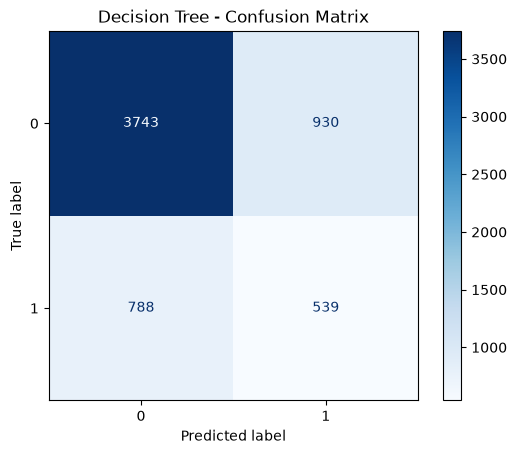

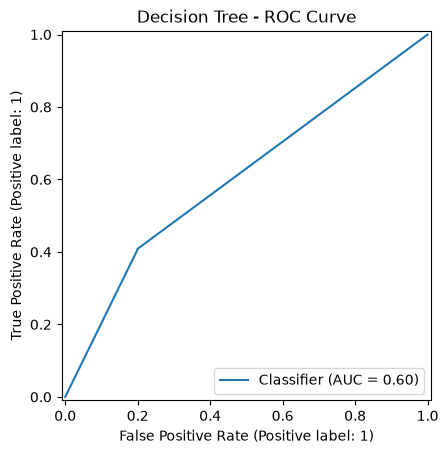

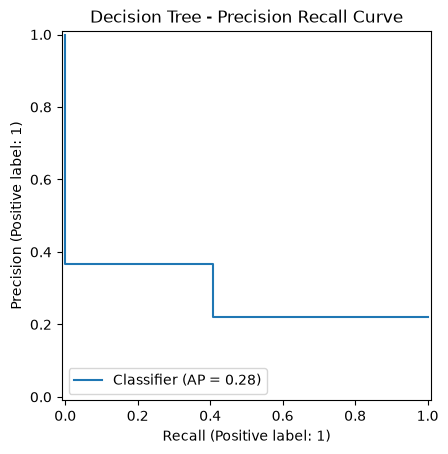



Generalização do Modelo
Accuracy Treino : 0.9995
Accuracy Teste  : 0.7137

ROC AUC Treino  : 1.0000
ROC AUC Teste   : 0.6042

Gap Accuracy : 0.2858
Gap ROC AUC  : 0.3958

⚠️ Possível overfitting detectado.


In [ ]:
# ============================================================
# Avaliação do Modelo
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# ============================================================
# Predições
# ============================================================

y_pred = tree_pipeline.predict(X_test)
y_prob = tree_pipeline.predict_proba(X_test)[:, 1]

train_pred = tree_pipeline.predict(X_train)
train_prob = tree_pipeline.predict_proba(X_train)[:, 1]

# ============================================================
# Métricas
# ============================================================

print("=" * 50)
print("Decision Tree - Baseline")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

# ============================================================
# Classification Report
# ============================================================

print("\n")
print("=" * 50)
print("Classification Report")
print("=" * 50)

print(classification_report(y_test, y_pred))

# ============================================================
# Matriz de Confusão
# ============================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Decision Tree - Confusion Matrix")
plt.show()

# ============================================================
# Curva ROC
# ============================================================

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Decision Tree - ROC Curve")
plt.show()

# ============================================================
# Precision x Recall
# ============================================================

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Decision Tree - Precision Recall Curve")
plt.show()

# ============================================================
# Avaliação de Overfitting
# ============================================================

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

train_auc = roc_auc_score(y_train, train_prob)
test_auc = roc_auc_score(y_test, y_prob)

print("\n")
print("=" * 50)
print("Generalização do Modelo")
print("=" * 50)

print(f"Accuracy Treino : {train_accuracy:.4f}")
print(f"Accuracy Teste  : {test_accuracy:.4f}")

print()

print(f"ROC AUC Treino  : {train_auc:.4f}")
print(f"ROC AUC Teste   : {test_auc:.4f}")

print()

gap_acc = train_accuracy - test_accuracy
gap_auc = train_auc - test_auc

print(f"Gap Accuracy : {gap_acc:.4f}")
print(f"Gap ROC AUC  : {gap_auc:.4f}")

if gap_acc > 0.10:
    print("\n⚠️ Possível overfitting detectado.")
else:
    print("\n✅ Não foram encontrados indícios fortes de overfitting.")

In [ ]:
# ============================================================
# Decision Tree - Grid Search
# ============================================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# ============================================================
# Modelo
# ============================================================

decision_tree = DecisionTreeClassifier(
    random_state=42
)

# ============================================================
# Pipeline
# ============================================================

tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", decision_tree)
    ]
)

# ============================================================
# Espaço de busca
# ============================================================

param_grid = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2, 10],
    "classifier__min_samples_leaf": [1, 5]
}

# ============================================================
# Validação Cruzada
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================================
# Grid Search
# ============================================================

grid_search = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    verbose=2,
    refit=True
)

# ============================================================
# Treinamento
# ============================================================

grid_search.fit(
    X_train,
    y_train
)

# ============================================================
# Melhor Modelo
# ============================================================

best_tree = grid_search.best_estimator_

print("=" * 50)
print("Melhores Hiperparâmetros")
print("=" * 50)

print(grid_search.best_params_)

print()

print(f"Melhor ROC AUC (CV): {grid_search.best_score_:.4f}")

# ============================================================
# Salvando modelo
# ============================================================

joblib.dump(
    best_tree,
    MODELS_DIR / "decision_tree_tuned.pkl"
)

print("\nModelo otimizado salvo com sucesso!")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END classifier__criterion=gini, classifier__max_depth=5, classifier__min_samples_leaf=1, classifier__min_samples_split=2; total time=   0.1s
[CV] END classifier__criterion=gini, classifier__max_depth=5, classifier__min_samples_leaf=1, classifier__min_samples_split=2; total time=   0.1s
[CV] END classifier__criterion=gini, classifier__max_depth=5, classifier__min_samples_leaf=1, classifier__min_samples_split=2; total time=   0.1s
[CV] END classifier__criterion=gini, classifier__max_depth=5, classifier__min_samples_leaf=1, classifier__min_samples_split=2; total time=   0.1s
[CV] END classifier__criterion=gini, classifier__max_depth=5, classifier__min_samples_leaf=1, classifier__min_samples_split=2; total time=   0.1s
[CV] END classifier__criterion=gini, classifier__max_depth=5, classifier__min_samples_leaf=1, classifier__min_samples_split=10; total time=   0.1s
[CV] END classifier__criterion=gini, classifier__max_depth=5,

Decision Tree - Grid Search
Accuracy : 0.8173
Precision: 0.6634
Recall   : 0.3534
F1 Score : 0.4612
ROC AUC  : 0.7477


Classification Report
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



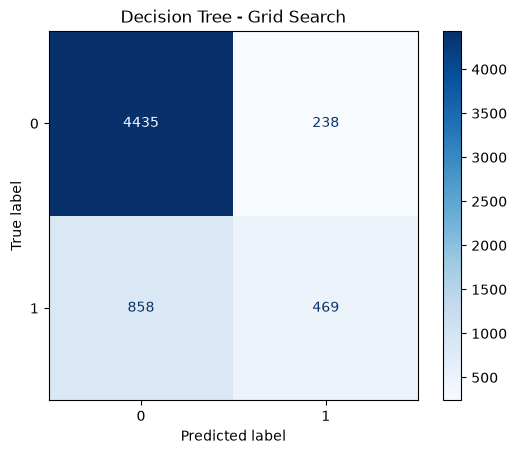

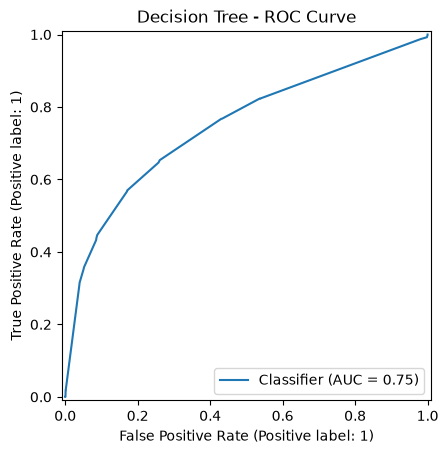

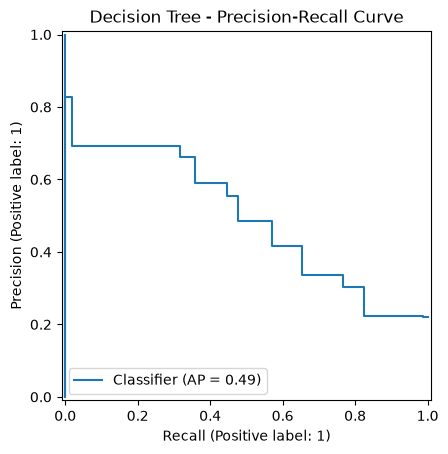



Generalização do Modelo
Accuracy Treino : 0.8247
Accuracy Teste  : 0.8173

ROC AUC Treino  : 0.7655
ROC AUC Teste   : 0.7477

Gap Accuracy : 0.0074
Gap ROC AUC  : 0.0178

✅ Não foram encontrados indícios fortes de overfitting.


In [ ]:
# ============================================================
# Avaliação da Decision Tree Otimizada
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# ============================================================
# Predições
# ============================================================

y_pred = best_tree.predict(X_test)
y_prob = best_tree.predict_proba(X_test)[:, 1]

train_pred = best_tree.predict(X_train)
train_prob = best_tree.predict_proba(X_train)[:, 1]

# ============================================================
# Métricas
# ============================================================

print("=" * 50)
print("Decision Tree - Grid Search")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

# ============================================================
# Classification Report
# ============================================================

print("\n")
print("=" * 50)
print("Classification Report")
print("=" * 50)

print(classification_report(y_test, y_pred))

# ============================================================
# Matriz de Confusão
# ============================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Decision Tree - Grid Search")
plt.show()

# ============================================================
# Curva ROC
# ============================================================

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Decision Tree - ROC Curve")
plt.show()

# ============================================================
# Curva Precision-Recall
# ============================================================

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Decision Tree - Precision-Recall Curve")
plt.show()

# ============================================================
# Generalização do Modelo
# ============================================================

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

train_auc = roc_auc_score(y_train, train_prob)
test_auc = roc_auc_score(y_test, y_prob)

print("\n")
print("=" * 50)
print("Generalização do Modelo")
print("=" * 50)

print(f"Accuracy Treino : {train_accuracy:.4f}")
print(f"Accuracy Teste  : {test_accuracy:.4f}")

print()

print(f"ROC AUC Treino  : {train_auc:.4f}")
print(f"ROC AUC Teste   : {test_auc:.4f}")

print()

gap_acc = train_accuracy - test_accuracy
gap_auc = train_auc - test_auc

print(f"Gap Accuracy : {gap_acc:.4f}")
print(f"Gap ROC AUC  : {gap_auc:.4f}")

if gap_acc > 0.10:
    print("\n⚠️ Possível overfitting detectado.")
else:
    print("\n✅ Não foram encontrados indícios fortes de overfitting.")

            Variável  Importância
27        ord__PAY_0     0.636982
28        ord__PAY_2     0.156731
9      num__PAY_AMT2     0.070167
30        ord__PAY_4     0.033749
2     num__BILL_AMT1     0.026172
0     num__LIMIT_BAL     0.019783
11     num__PAY_AMT4     0.015585
31        ord__PAY_5     0.008751
32        ord__PAY_6     0.007376
29        ord__PAY_3     0.004672
1           num__AGE     0.004332
12     num__PAY_AMT5     0.004109
13     num__PAY_AMT6     0.003568
21  cat__EDUCATION_5     0.003517
6     num__BILL_AMT5     0.003223
5     num__BILL_AMT4     0.001284
8      num__PAY_AMT1     0.000000
16  cat__EDUCATION_0     0.000000
15        cat__SEX_2     0.000000
14        cat__SEX_1     0.000000


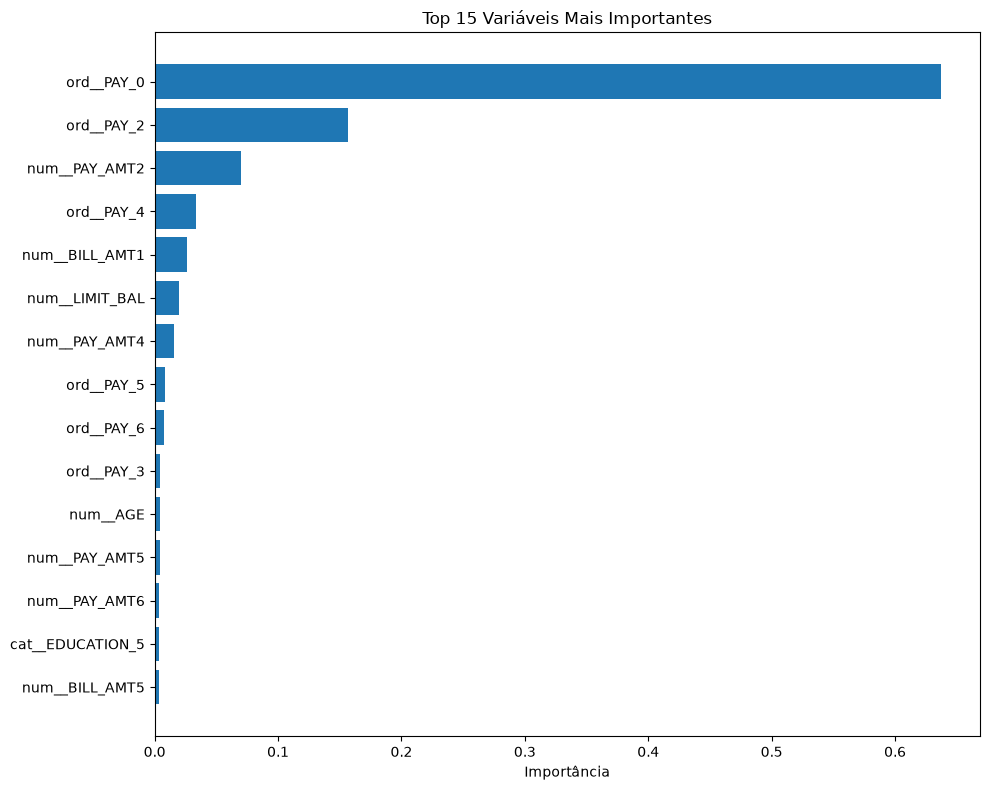

In [ ]:
# ============================================================
# Importância das Variáveis
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Obtém os nomes das variáveis após o pré-processamento
feature_names = best_tree.named_steps[
    "preprocessor"
].get_feature_names_out()

# Importâncias
importance = best_tree.named_steps[
    "classifier"
].feature_importances_

# DataFrame
importance_df = pd.DataFrame({
    "Variável": feature_names,
    "Importância": importance
})

importance_df = importance_df.sort_values(
    by="Importância",
    ascending=False
)

print(importance_df.head(20))

# ============================================================
# Gráfico
# ============================================================

plt.figure(figsize=(10,8))

plt.barh(
    importance_df["Variável"][:15][::-1],
    importance_df["Importância"][:15][::-1]
)

plt.title("Top 15 Variáveis Mais Importantes")
plt.xlabel("Importância")

plt.tight_layout()
plt.show()

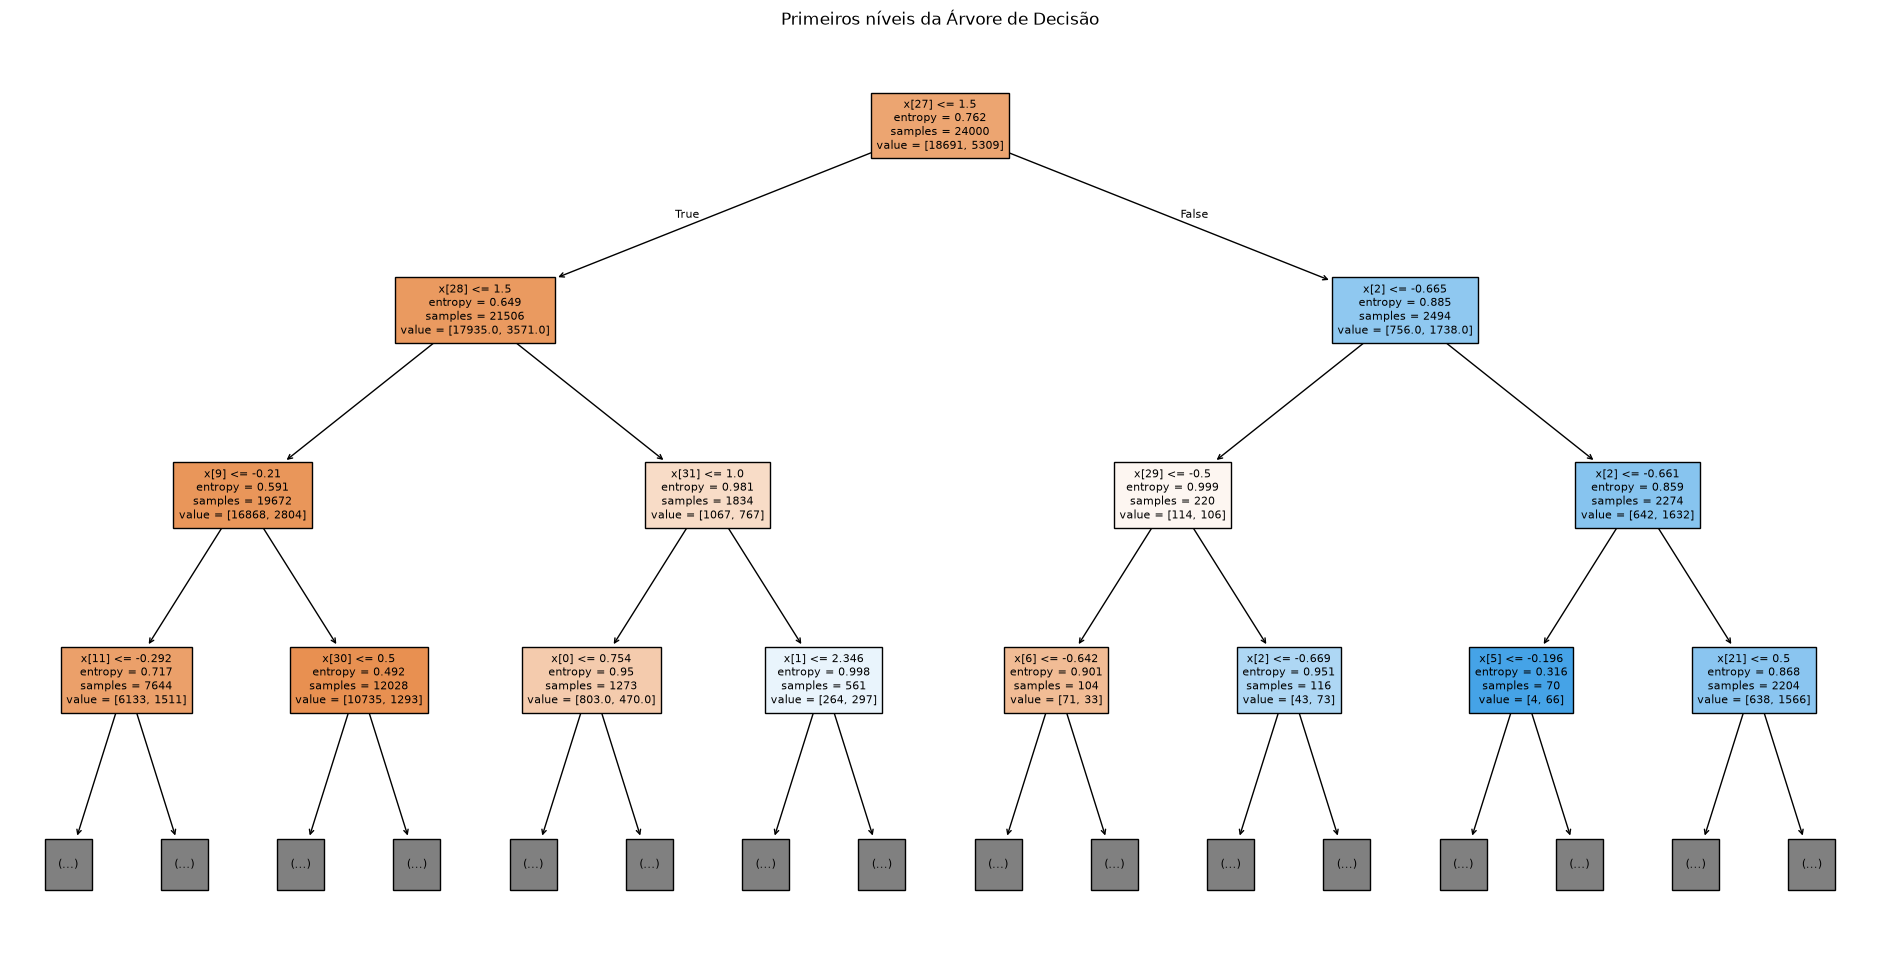

In [ ]:
# ============================================================
# Visualização da Árvore
# ============================================================

from sklearn.tree import plot_tree

plt.figure(figsize=(24,12))

plot_tree(
    best_tree.named_steps["classifier"],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("Primeiros níveis da Árvore de Decisão")

plt.show()

In [ ]:
# ============================================================
# Regras da Árvore
# ============================================================

from sklearn.tree import export_text

rules = export_text(
    best_tree.named_steps["classifier"],
    max_depth=4
)

print(rules)

|--- feature_27 <= 1.50
|   |--- feature_28 <= 1.50
|   |   |--- feature_9 <= -0.21
|   |   |   |--- feature_11 <= -0.29
|   |   |   |   |--- feature_2 <= -0.69
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_2 >  -0.69
|   |   |   |   |   |--- class: 0
|   |   |   |--- feature_11 >  -0.29
|   |   |   |   |--- feature_32 <= -1.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_32 >  -1.50
|   |   |   |   |   |--- class: 0
|   |   |--- feature_9 >  -0.21
|   |   |   |--- feature_30 <= 0.50
|   |   |   |   |--- feature_0 <= -0.71
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_0 >  -0.71
|   |   |   |   |   |--- class: 0
|   |   |   |--- feature_30 >  0.50
|   |   |   |   |--- feature_9 <= 0.28
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_9 >  0.28
|   |   |   |   |   |--- class: 0
|   |--- feature_28 >  1.50
|   |   |--- feature_31 <= 1.00
|   |   |   |--- feature_0 <= 0.75
|   |   |   |   |--- feature_13 <= 0.12
|   |   |  

In [ ]:
# ============================================================
# Complexidade da Árvore
# ============================================================

tree = best_tree.named_steps["classifier"]

print("="*50)
print("Complexidade da Árvore")
print("="*50)

print(f"Profundidade : {tree.get_depth()}")

print(f"Número de nós: {tree.tree_.node_count}")

print(f"Número de folhas: {tree.get_n_leaves()}")

Complexidade da Árvore
Profundidade : 5
Número de nós: 57
Número de folhas: 29
